In [1]:
from pathlib import Path
import zipfile
import pandas as pd

DATA_DIR = Path("../data/raw_consumption_by_fsa")

def load_month(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        csv_name = z.namelist()[0]

        with z.open(csv_name) as f:
            df = pd.read_csv(f, skiprows=3)

    return df

#### Just use 2 months of data (2026 Jan and Feb)

In [3]:
all_dfs = []

for zip_file in sorted(DATA_DIR.glob("*.zip")):
    if "202601_v1" in zip_file.name or "202602_v1" in zip_file.name:
        print(f"Loading {zip_file.name}")

        df = load_month(zip_file)

        all_dfs.append(df)

raw_df = pd.concat(all_dfs, ignore_index=True)

print(raw_df.shape)

Loading PUB_HourlyConsumptionByFSA_202601_v1.zip
Loading PUB_HourlyConsumptionByFSA_202602_v1.zip
(2903007, 7)


### Create Timestamp

In [3]:
raw_df["timestamp"] = (
    pd.to_datetime(raw_df["DATE"])
    + pd.to_timedelta(raw_df["HOUR"] - 1, unit="h")
)

### Aggregate to Ontario-Wide Consumption

In [4]:
ontario_hourly = (
    raw_df.groupby("timestamp", as_index=False)
          .agg({
              "TOTAL_CONSUMPTION": "sum",
              "PREMISE_COUNT": "sum"
          })
          .sort_values("timestamp")
)

In [5]:
ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
0,2026-01-01 00:00:00,7061893.0,5274850
1,2026-01-01 01:00:00,6815347.1,5274590
2,2026-01-01 02:00:00,6604055.2,5274380
3,2026-01-01 03:00:00,6458992.2,5273625
4,2026-01-01 04:00:00,6405967.8,5272157


In [6]:
ontario_hourly.tail()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
1411,2026-02-28 19:00:00,8.171924e+06,5295595
1412,2026-02-28 20:00:00,7.963853e+06,5295593
1413,2026-02-28 21:00:00,7.678498e+06,5295588
1414,2026-02-28 22:00:00,7.263470e+06,5295588
1415,2026-02-28 23:00:00,6.819851e+06,5297273


In [7]:
ontario_hourly.shape

(1416, 3)

### Verify Continuity
Very important for time-series.

In [8]:
ontario_hourly["timestamp"].diff().value_counts()

timestamp
0 days 01:00:00    1415
Name: count, dtype: int64

### Plot

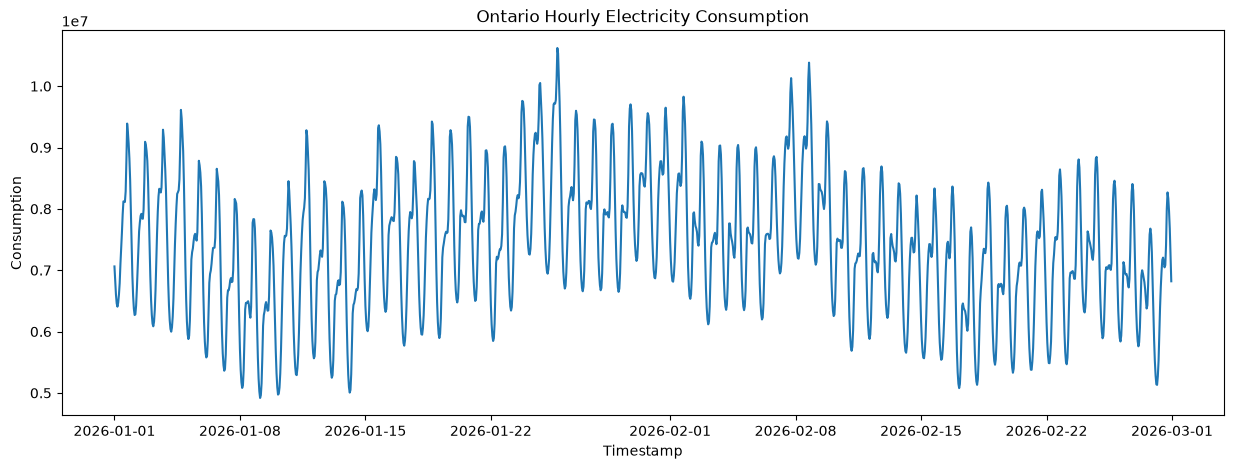

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    ontario_hourly["timestamp"],
    ontario_hourly["TOTAL_CONSUMPTION"]
)

plt.title("Ontario Hourly Electricity Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Consumption")
plt.show()

### Make sure it's sorted

In [10]:
ontario_hourly = ontario_hourly.sort_values("timestamp").reset_index(drop=True)

# Feature Engineering

Time-series forecasting models require historical information to be transformed into predictive features.

The following features are created:

### Calendar Features

- Hour of day
- Day of week
- Day of month
- Month

### Lag Features

- Previous hour demand (lag_1)
- Previous day demand (lag_24)
- Previous week demand (lag_168)

### Rolling Statistics

- 24-hour rolling mean
- 168-hour rolling mean

These features help capture daily and weekly electricity consumption patterns.


In [11]:
ontario_hourly["hour"] = ontario_hourly["timestamp"].dt.hour
ontario_hourly["day_of_week"] = ontario_hourly["timestamp"].dt.dayofweek
ontario_hourly["month"] = ontario_hourly["timestamp"].dt.month
ontario_hourly["day_of_month"] = ontario_hourly["timestamp"].dt.day


In [12]:
ontario_hourly["lag_1"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(1)
)

ontario_hourly["lag_24"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(24)
)

ontario_hourly["lag_168"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(168)
)

In [14]:
ontario_hourly["rolling_mean_24"] = (
    ontario_hourly["TOTAL_CONSUMPTION"]
    .rolling(24)
    .mean()
)

ontario_hourly["rolling_mean_168"] = (
    ontario_hourly["TOTAL_CONSUMPTION"]
    .rolling(168)
    .mean()
)

In [16]:
ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT,hour,day_of_week,month,day_of_month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
0,2026-01-01 00:00:00,7061893.0,5274850,0,3,1,1,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 01:00:00,6815347.1,5274590,1,3,1,1,7061893.0,NaN,NaN,NaN,NaN
2,2026-01-01 02:00:00,6604055.2,5274380,2,3,1,1,6815347.1,NaN,NaN,NaN,NaN
3,2026-01-01 03:00:00,6458992.2,5273625,3,3,1,1,6604055.2,NaN,NaN,NaN,NaN
4,2026-01-01 04:00:00,6405967.8,5272157,4,3,1,1,6458992.2,NaN,NaN,NaN,NaN


In [17]:
model_df = ontario_hourly.dropna().copy()

model_df.shape

(1248, 12)

In [18]:
FEATURES = [
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

TARGET = "TOTAL_CONSUMPTION"

X = model_df[FEATURES]
y = model_df[TARGET]

In [19]:
split_idx = int(len(model_df) * 0.8)

train = model_df.iloc[:split_idx]
test = model_df.iloc[split_idx:]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [20]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [21]:
predictions = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE: 103,569.33
RMSE: 137,513.97


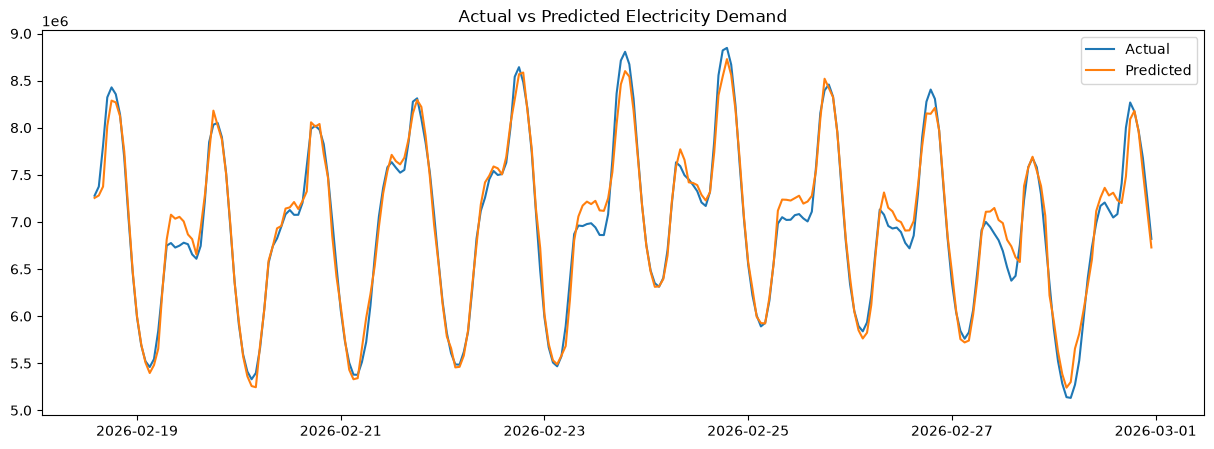

In [23]:
plt.figure(figsize=(15,5))

plt.plot(
    test["timestamp"],
    y_test,
    label="Actual"
)

plt.plot(
    test["timestamp"],
    predictions,
    label="Predicted"
)

plt.legend()
plt.title("Actual vs Predicted Electricity Demand")

plt.show()

### Naive prediction (24 hours ago used as current hour consumption)

In [25]:
from sklearn.metrics import mean_absolute_error

baseline_pred = test["lag_24"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

print("Baseline MAE:", round(baseline_mae, 2))
print("XGBoost MAE :", round(mae, 2))

Baseline MAE: 328806.47
XGBoost MAE : 103569.33


In [27]:
# percentage 
mape = (
    abs((y_test - predictions) / y_test)
).mean() * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 1.49%


In [28]:
feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
})

feature_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
4,lag_1,0.903746
5,lag_24,0.045076
0,hour,0.031728
7,rolling_mean_24,0.006519
8,rolling_mean_168,0.003581
6,lag_168,0.003410
1,day_of_week,0.002411
3,day_of_month,0.002298
2,month,0.001231


In [30]:
baseline_pred = test["lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

print(baseline_mae)
print(mae)


249238.40475075203
103569.331058372
